# I Love Python 
## Credit Models

- José Armando Melchor Soto


---

### Libraries

In [ ]:
import pandas as pd
from viz import Visualization
from xgboost.sklearn import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

---

### Dataset

In [218]:
data = pd.read_csv("data.csv")
data.head()

,id,creditLimit,gender,edu,age,nDelay,billAmt1,billAmt2,billAmt3,billAmt4,billAmt5,billAmt6,default
0,1,1500,0,3,31,2,1350,1530,1455,1515,1530,1515,0
1,2,10900,0,1,47,0,8720,9047,9374,0,0,2834,0
2,3,3600,1,2,54,3,2520,2448,2808,2736,2700,2880,1
3,4,4200,0,1,25,0,4116,3990,3906,1764,1722,1722,0
4,5,19200,0,5,53,0,12864,13056,12864,6144,3840,11904,0


In [219]:
data.keys()

Index(['id', 'creditLimit', 'gender', 'edu', 'age', 'nDelay', 'billAmt1',
       'billAmt2', 'billAmt3', 'billAmt4', 'billAmt5', 'billAmt6', 'default'],
      dtype='object')

----

### ML Models

### Target

In [220]:
y = data["default"]

### Features

In [221]:
X = data[['id', 'creditLimit', 'gender', 'edu', 'age', 'nDelay', 'billAmt1',
       'billAmt2', 'billAmt3', 'billAmt4', 'billAmt5', 'billAmt6']]

### Split

In [222]:
X_train , X_test , y_train , y_test =  train_test_split(
    X , y , test_size = 0.25 , random_state= 42)

### Logistic Regression

In [223]:
model = LogisticRegression(max_iter= 1000)
model.fit(X_train , y_train)

c:\Users\ppmel\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [224]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [233]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.78
AUC: 0.7840350877192982


### XGBoost  

In [226]:
model_XGB = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    subsample=0.08,
    colsample_bytree=0.8,
    learning_rate=0.05,
    random_state=42,
    
)
model_XGB.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [227]:
y_pred_XGB = model_XGB.predict(X_test)
y_prob_XGB = model_XGB.predict_proba(X_test)[:,1]

In [234]:
print("Accuracy:", accuracy_score(y_test, y_pred_XGB))
print("AUC:", roc_auc_score(y_test, y_prob_XGB))

Accuracy: 0.792
AUC: 0.8129824561403509


---

### Visualization

In [229]:
viz = Visualization(data)

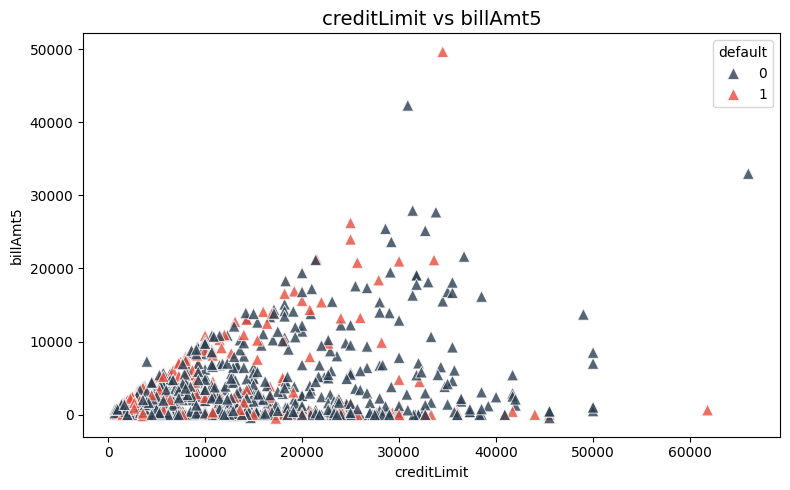

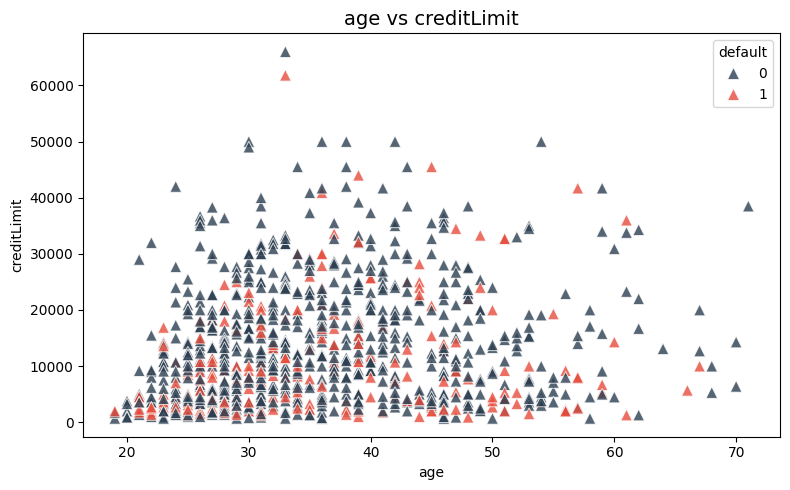

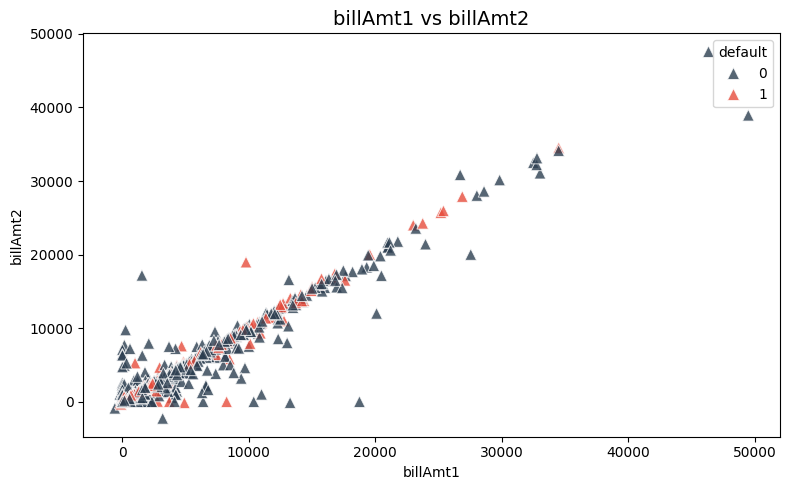

In [230]:
viz.scatter("creditLimit", "billAmt5")
viz.scatter("age", "creditLimit")
viz.scatter("billAmt1", "billAmt2")

#### Logistic Regression

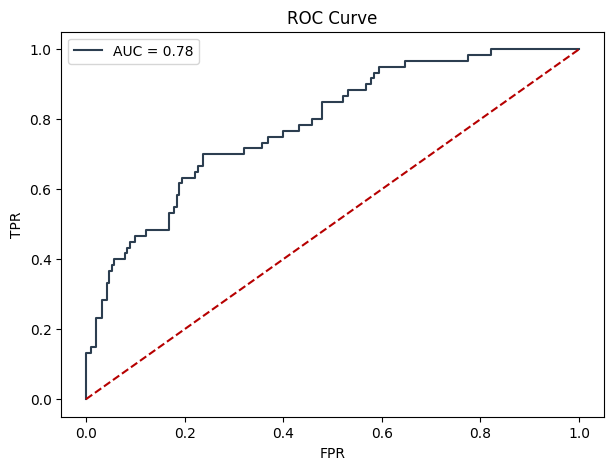

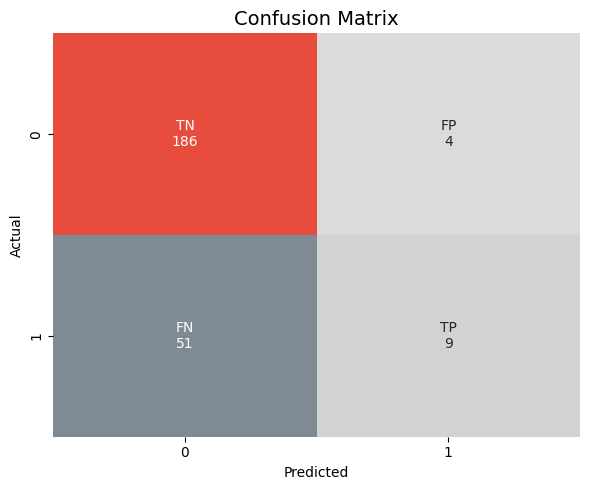

In [231]:
viz.roc_curve(y_test, y_prob)
viz.confusion_matrix(y_test, y_pred)

#### XGBoost

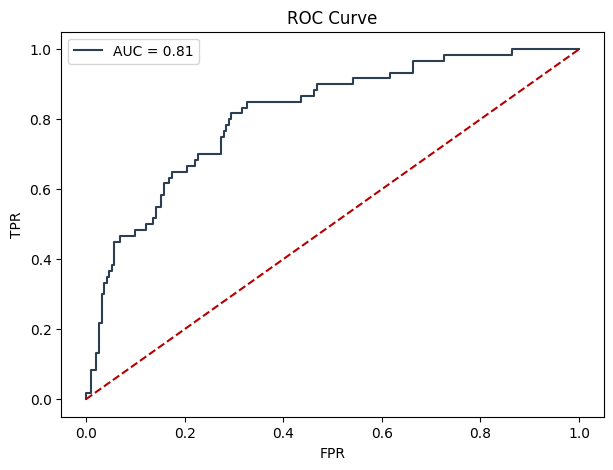

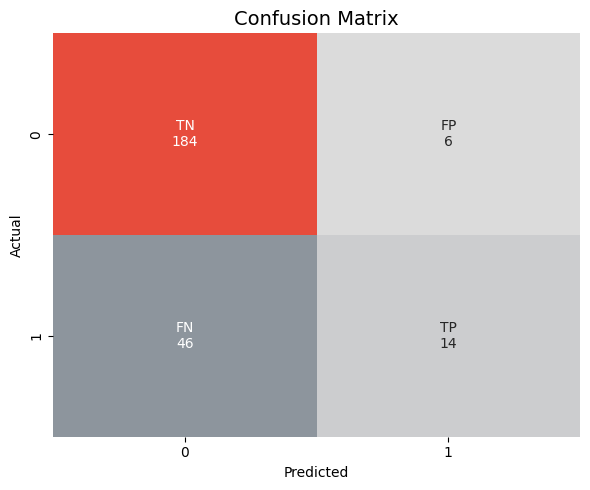

In [232]:
viz.roc_curve(y_test, y_prob_XGB)
viz.confusion_matrix(y_test, y_pred_XGB)

---

### Conclusions

The XGBoost model demonstrated superior performance in predicting credit default, achieving an AUC of 0.813 and an accuracy of approximately 0.79. These results indicate that the model has a strong overall ability to distinguish between customers who will default and those who will not. Compared to Logistic Regression, XGBoost benefits from its ability to capture non-linear relationships and complex interactions among variables.

From the exploratory analysis, financial variables such as billing amounts (billAmt1–billAmt6) and the number of delayed payments (nDelay) appear to be particularly relevant in explaining default behavior. These features reflect the customer's financial activity and repayment patterns, making them strong indicators of credit risk. However, the visualizations reveal a significant overlap between the default and non-default classes, suggesting that no single variable is sufficient to clearly separate the two groups.

This overlap highlights that credit default is a multifactorial phenomenon, driven by the interaction of several variables rather than a single dominant predictor. As a result, even with a relatively strong model like XGBoost, some misclassification errors persist, particularly false negatives, where default cases are incorrectly classified as non-default. This is a critical limitation in risk-related applications, as these cases represent potentially high-risk customers.

In conclusion, while XGBoost provides better predictive performance, especially in terms of AUC, the results suggest that further improvements could be achieved through feature engineering, better handling of class imbalance, or additional model tuning. Moreover, evaluating performance using metrics beyond accuracy, such as AUC, is essential in order to obtain a more reliable assessment of model effectiveness in classification problems of this nature.

---

### Sources

- NumPy Developers. (2024). NumPy documentation. https://numpy.org/doc/
- Matplotlib Development Team. (2024). Matplotlib documentation. https://matplotlib.org/stable/contents.html
- Waskom, M. (2024). Seaborn documentation. https://seaborn.pydata.org/
- Scikit-learn Developers. (2024). Scikit-learn documentation. https://scikit-learn.org/stable/documentation.html
- XGBoost Developers. (2024). XGBoost documentation. https://xgboost.readthedocs.io/